# Cross Dataset Experiment 

In this notebook, we compare the performance of three models: Random Forest Classifier, Logistic Regression and XGBoost against our 3 cleaned datasets. We also applied class weighting across all models to address class imbalance. The results of each experiment is recorded and will evaluated at the end of this notebook.

In [50]:
#All imports needed for this experiment

import pandas as pd
import os
import joblib

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [51]:
# Load cleaned datasets
df1 = pd.read_csv("data/cleaned/dataset_1/dataset_1_clean.csv")
df2 = pd.read_csv("data/cleaned/dataset_2/dataset_2_clean.csv")
df3 = pd.read_csv("data/cleaned/dataset_3/dataset_3_clean.csv")

print("Datasets Loaded in successfully.")

Datasets Loaded in successfully.


## Feature Alignment

In [52]:
# Find common columns across all three datasets
common_cols = [col for col in df1.columns if col in df2.columns and col in df3.columns]

print(f"Number of columns in dataset 1: {len(df1.columns)}")
print(f"Number of columns in dataset 2: {len(df2.columns)}")
print(f"Number of columns in dataset 3: {len(df3.columns)}\n")
print("Number of common columns among 3 datasets:", len(common_cols))

# Keep only common columns in each dataset
df1 = df1[common_cols].copy()
df2 = df2[common_cols].copy()
df3 = df3[common_cols].copy()

if(df1.columns.tolist() == df2.columns.tolist() == df3.columns.tolist()):
    print("\nAll none common columns removed from datasets")

Number of columns in dataset 1: 26
Number of columns in dataset 2: 14
Number of columns in dataset 3: 43

Number of common columns among 3 datasets: 14

All none common columns removed from datasets


## Data Splitting

In [53]:
def split_data(df):
    X = df.drop("target", axis=1)
    y = df["target"]
    
    return train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X1_train, X1_test, y1_train, y1_test = split_data(df1)
X2_train, X2_test, y2_train, y2_test = split_data(df2)
X3_train, X3_test, y3_train, y3_test = split_data(df3)

print("The datasets have been split into 3 seperate x_train, x_test and y_train, y_test")

The datasets have been split into 3 seperate x_train, x_test and y_train, y_test


In [54]:
numeric_features = X1_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X1_train.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features in dataset:", numeric_features)
print("Categorical features in dataset:", categorical_features)

Numeric features in dataset: ['bp', 'sg', 'al', 'su', 'bu', 'sc', 'sod', 'pot', 'hemo']
Categorical features in dataset: ['rbc', 'wc', 'rc', 'htn']


## Preprocessing Pipeline

In [55]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Our preprocessor is defined as follows: ")
print(preprocessor)

Our preprocessor is defined as follows: 
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['bp', 'sg', 'al', 'su', 'bu', 'sc', 'sod',
                                  'pot', 'hemo']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['rbc', 'wc', 'rc', 'htn'])])


In [85]:
#Saving the numeric and categorical features for future use in feature importance analysis
print("Saving numeric and categorical features...")
joblib.dump(numeric_features, 'models/numeric_features.joblib')
joblib.dump(categorical_features, 'models/categorical_features.joblib')

Saving numeric and categorical features...


['models/categorical_features.joblib']

In [56]:
# Function to compute all metrics at once
def get_metrics(model, X, y):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]
    return {
        "accuracy": accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred, zero_division=0),
        "recall": recall_score(y, y_pred, zero_division=0),
        "f1": f1_score(y, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y, y_prob)
    }

In [57]:
# Initialize results list
results = []

### NOTE: Running The Below Experiments Over Will Create New Results Entries

---
# Dataset 1 Experiments
---

## Preprocessing for Dataset 1

In [58]:
# Fit preprocessor on D1 ONLY
X1_train_t = preprocessor.fit_transform(X1_train)

# Transform ALL test sets using SAME preprocessor
X1_test_t = preprocessor.transform(X1_test)
X2_test_t = preprocessor.transform(X2_test)
X3_test_t = preprocessor.transform(X3_test)

In [59]:
#Saving the Dataset 1 Preprocessor
print("Saving the preprocessor for dataset 1...")
joblib.dump(preprocessor, 'models/dataset_1/preprocessor.joblib')
print("Preprocessor saved.")

Saving the preprocessor for dataset 1...
Preprocessor saved.


## Experiment 1
- Training Dataset: 1
- Model: Random Forest Classifer
- Imbalance Handling: None


In [60]:
model = RandomForestClassifier(random_state=42)

print("Training RandomForestClassifier model on dataset 1 (No Imbalance Handling)...")
model.fit(X1_train_t, y1_train)
print("Training Finished!")

for test_set, X_test, y_test in [(1, X1_test_t, y1_test), (2, X2_test_t, y2_test), (3, X3_test_t, y3_test)]:
    results.append({'train_dataset': 1, 'test_dataset': test_set, 'model': 'Random Forest', 'imbalance_handling': 'None', **get_metrics(model, X_test, y_test)})

#Save the dataset 1 models for future feature analysis and tuning
os.makedirs('models/dataset_1', exist_ok=True)

print("\nSaving model...")
joblib.dump(model, 'models/dataset_1/RandomForestClassifier_base.joblib')

Training RandomForestClassifier model on dataset 1 (No Imbalance Handling)...
Training Finished!

Saving model...


['models/dataset_1/RandomForestClassifier_base.joblib']

## Experiment 2
- Training Dataset: 1
- Model: Random Forest Classifier 
- Imbalance Handling: Weights

In [61]:
model = RandomForestClassifier(class_weight="balanced", random_state=42)

print("Training RandomForestClassifier model on dataset 1 (Weight Imbalance Handling)...")
model.fit(X1_train_t, y1_train)
print("Training Finished!")

for test_set, X_test, y_test in [(1, X1_test_t, y1_test), (2, X2_test_t, y2_test), (3, X3_test_t, y3_test)]:
    results.append({'train_dataset': 1, 'test_dataset': test_set, 'model': 'Random Forest', 'imbalance_handling': 'Balanced', **get_metrics(model, X_test, y_test)})

print("\nSaving model...")
joblib.dump(model, 'models/dataset_1/RandomForestClassifier_weighted.joblib')

Training RandomForestClassifier model on dataset 1 (Weight Imbalance Handling)...
Training Finished!

Saving model...


['models/dataset_1/RandomForestClassifier_weighted.joblib']

## Experiment 3
- Training Dataset: 1
- Model: Logistic Regression
- Imbalance Handling: None

In [62]:
model = LogisticRegression(max_iter=1000, random_state=42)

print("Training LogisiticRegression model on dataset 1 (No Imbalance Handling...)")
model.fit(X1_train_t, y1_train)
print("Training Finished!")

for test_set, X_test, y_test in [(1, X1_test_t, y1_test), (2, X2_test_t, y2_test), (3, X3_test_t, y3_test)]:
    results.append({'train_dataset': 1, 'test_dataset': test_set, 'model': 'Logistic Regression', 'imbalance_handling': 'None', **get_metrics(model, X_test, y_test)})

print("\nSaving model...")
joblib.dump(model, 'models/dataset_1/LogisticRegression_base.joblib')

Training LogisiticRegression model on dataset 1 (No Imbalance Handling...)
Training Finished!

Saving model...


['models/dataset_1/LogisticRegression_base.joblib']

## Experiment 4
- Training Dataset: 1
- Model: Logistic Regression
- Imbalance Handling: Weights

In [63]:
model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)

print("Training LogisiticRegression model on dataset 1 (Weight Imbalance Handling...)")
model.fit(X1_train_t, y1_train)
print("Training Finished!")

for test_set, X_test, y_test in [(1, X1_test_t, y1_test), (2, X2_test_t, y2_test), (3, X3_test_t, y3_test)]:
    results.append({'train_dataset': 1, 'test_dataset': test_set, 'model': 'Logistic Regression', 'imbalance_handling': 'Balanced', **get_metrics(model, X_test, y_test)})

print("\nSaving model...")
joblib.dump(model, 'models/dataset_1/LogisticRegression_weighted.joblib')

Training LogisiticRegression model on dataset 1 (Weight Imbalance Handling...)
Training Finished!

Saving model...


['models/dataset_1/LogisticRegression_weighted.joblib']

## Experiment 5
- Training Dataset: 1
- Model: XGBoost
- Imbalance Handling: None

In [64]:
model = XGBClassifier(random_state=42, eval_metric="logloss")

print("Training XGBoostClassifier model on dataset 1 (No Imbalance Handling)...")
model.fit(X1_train_t, y1_train)
print("Training Finished!")

for test_set, X_test, y_test in [(1, X1_test_t, y1_test), (2, X2_test_t, y2_test), (3, X3_test_t, y3_test)]:
    results.append({'train_dataset': 1, 'test_dataset': test_set, 'model': 'XGBoost', 'imbalance_handling': 'None', **get_metrics(model, X_test, y_test)})

print("\nSaving model...")
joblib.dump(model, 'models/dataset_1/XGBClassifier_base.joblib')

Training XGBoostClassifier model on dataset 1 (No Imbalance Handling)...
Training Finished!

Saving model...


['models/dataset_1/XGBClassifier_base.joblib']

## Experiment 6
- Training Dataset: 1
- Model: XGBoost
- Imbalance Handling: Weights

In [65]:
neg = (y1_train == 0).sum()
pos = (y1_train == 1).sum()

model = XGBClassifier(
    scale_pos_weight=neg / pos,
    eval_metric="logloss",
    random_state=42
)

print("Training XGBoostClassifier model on dataset 1 (Weight Imbalance Handling)...")
model.fit(X1_train_t, y1_train)
print("Training Finished!")

for test_set, X_test, y_test in [(1, X1_test_t, y1_test), (2, X2_test_t, y2_test), (3, X3_test_t, y3_test)]:
    results.append({'train_dataset': 1, 'test_dataset': test_set, 'model': 'XGBoost', 'imbalance_handling': 'Balanced', **get_metrics(model, X_test, y_test)})

print("\nSaving model...")
joblib.dump(model, 'models/dataset_1/XGBClassifier_weighted.joblib')

Training XGBoostClassifier model on dataset 1 (Weight Imbalance Handling)...
Training Finished!

Saving model...


['models/dataset_1/XGBClassifier_weighted.joblib']

---
## Dataset 2 Experiments
---

## Preprocessing for Dataset 2

In [66]:
# Fit preprocessor on D2 ONLY
X2_train_t = preprocessor.fit_transform(X2_train)

# Transform ALL test sets using SAME preprocessor
X1_test_t = preprocessor.transform(X1_test)
X2_test_t = preprocessor.transform(X2_test)
X3_test_t = preprocessor.transform(X3_test)

In [67]:
#Saving the Dataset 2 Preprocessor
print("Saving the preprocessor for dataset 2...")
joblib.dump(preprocessor, 'models/dataset_2/preprocessor.joblib')
print("Preprocessor saved.")

Saving the preprocessor for dataset 2...
Preprocessor saved.


## Experiment 1
- Training Dataset: 2
- Model: Random Forest Classifier
- Imbalance Handling: None

In [68]:
model = RandomForestClassifier(random_state=42)

print("Training RandomForestClassifier model on dataset 2 (No Imbalance Handling)...")
model.fit(X2_train_t, y2_train)
print("Training finished!")

for test_set, X_test, y_test in [(1, X1_test_t, y1_test), (2, X2_test_t, y2_test), (3, X3_test_t, y3_test)]:
    results.append({'train_dataset': 2, 'test_dataset': test_set, 'model': 'Random Forest', 'imbalance_handling': 'None', **get_metrics(model, X_test, y_test)})

#Save the dataset 2 models for future feature analysis and tuning
os.makedirs('models/dataset_2', exist_ok=True)

print("\nSaving model...")
joblib.dump(model, 'models/dataset_2/RandomForestClassifier_base.joblib')

Training RandomForestClassifier model on dataset 2 (No Imbalance Handling)...


Training finished!

Saving model...


['models/dataset_2/RandomForestClassifier_base.joblib']

## Experiment 2
- Training Dataset: 2
- Model: Random Forest Classifier
- Imbalance Handling: Weights

In [69]:
model = RandomForestClassifier(class_weight="balanced", random_state=42)

print("Training RandomForestClassifier model on dataset 2 (Weight Imbalance Handling)...")
model.fit(X2_train_t, y2_train)
print("Training finished!")

for test_set, X_test, y_test in [(1, X1_test_t, y1_test), (2, X2_test_t, y2_test), (3, X3_test_t, y3_test)]:
    results.append({'train_dataset': 2, 'test_dataset': test_set, 'model': 'Random Forest', 'imbalance_handling': 'Balanced', **get_metrics(model, X_test, y_test)})

print("\nSaving model...")
joblib.dump(model, 'models/dataset_2/RandomForestClassifier_weighted.joblib')

Training RandomForestClassifier model on dataset 2 (Weight Imbalance Handling)...
Training finished!

Saving model...


['models/dataset_2/RandomForestClassifier_weighted.joblib']

## Experiment 3
- Training Dataset: 2
- Model: Logistic Regression
- Imbalance Handling: None

In [70]:
model = LogisticRegression(max_iter=1000, random_state=42)

print("Training LogisticRegression model on dataset 2 (No Imbalance Handling)...")
model.fit(X2_train_t, y2_train)
print("Training finished!")

for test_set, X_test, y_test in [(1, X1_test_t, y1_test), (2, X2_test_t, y2_test), (3, X3_test_t, y3_test)]:
    results.append({'train_dataset': 2, 'test_dataset': test_set, 'model': 'Logistic Regression', 'imbalance_handling': 'None', **get_metrics(model, X_test, y_test)})

print("\nSaving model...")
joblib.dump(model, 'models/dataset_2/LogisticRegression_base.joblib')

Training LogisticRegression model on dataset 2 (No Imbalance Handling)...
Training finished!

Saving model...


['models/dataset_2/LogisticRegression_base.joblib']

## Experiment 4
- Training Dataset: 2
- Model: Logistic Regression
- Imbalance Handling: Weights

In [71]:
model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)


print("Training LogisticRegression model on dataset 2 (Weight Imbalance Handling)...")
model.fit(X2_train_t, y2_train)
print("Training finished!")

for test_set, X_test, y_test in [(1, X1_test_t, y1_test), (2, X2_test_t, y2_test), (3, X3_test_t, y3_test)]:
    results.append({'train_dataset': 2, 'test_dataset': test_set, 'model': 'Logistic Regression', 'imbalance_handling': 'Balanced', **get_metrics(model, X_test, y_test)})

print("\nSaving model...")
joblib.dump(model, 'models/dataset_2/LogisticRegression_weighted.joblib')

Training LogisticRegression model on dataset 2 (Weight Imbalance Handling)...
Training finished!

Saving model...


['models/dataset_2/LogisticRegression_weighted.joblib']

## Experiment 5
- Training Dataset: 2
- Model: XGBoost
- Imbalance Handling: None

In [72]:
model = XGBClassifier(random_state=42, eval_metric="logloss")

print("Training XGBoostClassifier model on dataset 2 (No Imbalance Handling)...")
model.fit(X2_train_t, y2_train)
print("Training finished!")

for test_set, X_test, y_test in [(1, X1_test_t, y1_test), (2, X2_test_t, y2_test), (3, X3_test_t, y3_test)]:
    results.append({'train_dataset': 2, 'test_dataset': test_set, 'model': 'XGBoost', 'imbalance_handling': 'None', **get_metrics(model, X_test, y_test)})

print("\nSaving model...")
joblib.dump(model, 'models/dataset_2/XGBClassifier_base.joblib')

Training XGBoostClassifier model on dataset 2 (No Imbalance Handling)...
Training finished!

Saving model...


['models/dataset_2/XGBClassifier_base.joblib']

## Experiment 6
- Training Dataset: 2
- Model: XGBoost
- Imbalance Handling: Weights

In [73]:
neg = (y2_train == 0).sum()
pos = (y2_train == 1).sum()

model = XGBClassifier(
    scale_pos_weight=neg / pos,
    eval_metric="logloss",
    random_state=42
)

print("Training XGBoostClassifier model on dataset 2 (Weight Imbalance Handling)...")
model.fit(X2_train_t, y2_train)
print("Training finished!")

for test_set, X_test, y_test in [(1, X1_test_t, y1_test), (2, X2_test_t, y2_test), (3, X3_test_t, y3_test)]:
    results.append({'train_dataset': 2, 'test_dataset': test_set, 'model': 'XGBoost', 'imbalance_handling': 'Balanced', **get_metrics(model, X_test, y_test)})

print("\nSaving model...")
joblib.dump(model, 'models/dataset_2/XGBClassifier_weighted.joblib')

Training XGBoostClassifier model on dataset 2 (Weight Imbalance Handling)...
Training finished!

Saving model...


['models/dataset_2/XGBClassifier_weighted.joblib']

---
## Dataset 3 Experiments
___

## Preprocessing for Dataset 3

In [74]:
# Fit preprocessor on D3 ONLY
X3_train_t = preprocessor.fit_transform(X3_train)

# Transform ALL test sets using SAME preprocessor
X1_test_t = preprocessor.transform(X1_test)
X2_test_t = preprocessor.transform(X2_test)
X3_test_t = preprocessor.transform(X3_test)

In [75]:
#Saving the Dataset 3 Preprocessor
print("Saving the preprocessor for dataset 3...")
joblib.dump(preprocessor, 'models/dataset_3/preprocessor.joblib')
print("Preprocessor saved.")

Saving the preprocessor for dataset 3...
Preprocessor saved.


## Experiment 1
- Training Dataset: 3
- Model: Random Forest Classifier
- Imbalance Handling: None

In [76]:
model = RandomForestClassifier(random_state=42)

print("Training RandomForestClassifier model on dataset 3 (No Imbalance Handling)...")
model.fit(X3_train_t, y3_train)
print("Training Finished!")

for test_set, X_test, y_test in [(1, X1_test_t, y1_test), (2, X2_test_t, y2_test), (3, X3_test_t, y3_test)]:
    results.append({'train_dataset': 3, 'test_dataset': test_set, 'model': 'Random Forest', 'imbalance_handling': 'None', **get_metrics(model, X_test, y_test)})

#Save the dataset 3 models for future feature analysis and tuning
os.makedirs('models/dataset_3', exist_ok=True)

print("\nSaving model...")
joblib.dump(model, 'models/dataset_3/RandomForestClassifier_base.joblib')

Training RandomForestClassifier model on dataset 3 (No Imbalance Handling)...
Training Finished!

Saving model...


['models/dataset_3/RandomForestClassifier_base.joblib']

## Experiment 2
- Training Dataset: 3
- Model: Random Forest Classifier
- Imbalance Handling: Balanced

In [77]:
model = RandomForestClassifier(class_weight="balanced", random_state=42)

print("Training RandomForestClassifier model on dataset 3 (Weight Imbalance Handling)...")
model.fit(X3_train_t, y3_train)
print("Training Finished!")

for test_set, X_test, y_test in [(1, X1_test_t, y1_test), (2, X2_test_t, y2_test), (3, X3_test_t, y3_test)]:
    results.append({'train_dataset': 3, 'test_dataset': test_set, 'model': 'Random Forest', 'imbalance_handling': 'Balanced', **get_metrics(model, X_test, y_test)})

#Save the dataset 3 models for future feature analysis and tuning
os.makedirs('models/dataset_3', exist_ok=True)

print("\nSaving model...")
joblib.dump(model, 'models/dataset_3/RandomForestClassifier_weighted.joblib')

Training RandomForestClassifier model on dataset 3 (Weight Imbalance Handling)...
Training Finished!

Saving model...


['models/dataset_3/RandomForestClassifier_weighted.joblib']

## Experiment 3
- Training Dataset: 3
- Model: Logistic Regression
- Imbalance Handling: None

In [78]:
model = LogisticRegression(max_iter=1000, random_state=42)

print("Training LogisiticRegression model on dataset 3 (No Imbalance Handling...)")
model.fit(X3_train_t, y3_train)
print("Training Finished!")

for test_set, X_test, y_test in [(1, X1_test_t, y1_test), (2, X2_test_t, y2_test), (3, X3_test_t, y3_test)]:
    results.append({'train_dataset': 3, 'test_dataset': test_set, 'model': 'Logistic Regression', 'imbalance_handling': 'None', **get_metrics(model, X_test, y_test)})

print("\nSaving model...")
joblib.dump(model, 'models/dataset_3/LogisticRegression_base.joblib')

Training LogisiticRegression model on dataset 3 (No Imbalance Handling...)
Training Finished!

Saving model...


['models/dataset_3/LogisticRegression_base.joblib']

## Experiment 4
- Training Dataset: 3
- Model: Logistic Regression
- Imbalance Handling: Balanced

In [79]:
model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)

print("Training LogisiticRegression model on dataset 3 (Weight Imbalance Handling...)")
model.fit(X3_train_t, y3_train)
print("Training Finished!")

for test_set, X_test, y_test in [(1, X1_test_t, y1_test), (2, X2_test_t, y2_test), (3, X3_test_t, y3_test)]:
    results.append({'train_dataset': 3, 'test_dataset': test_set, 'model': 'Logistic Regression', 'imbalance_handling': 'Balanced', **get_metrics(model, X_test, y_test)})

print("\nSaving model...")
joblib.dump(model, 'models/dataset_3/LogisticRegression_weighted.joblib')

Training LogisiticRegression model on dataset 3 (Weight Imbalance Handling...)
Training Finished!

Saving model...


['models/dataset_3/LogisticRegression_weighted.joblib']

## Experiment 5
- Training Dataset: 3
- Model: XGBoost
- Imbalance Handling: None

In [80]:
model = XGBClassifier(random_state=42, eval_metric="logloss")

print("Training XGBoostClassifier model on dataset 3 (No Imbalance Handling)...")
model.fit(X3_train_t, y3_train)
print("Training Finished!")

for test_set, X_test, y_test in [(1, X1_test_t, y1_test), (2, X2_test_t, y2_test), (3, X3_test_t, y3_test)]:
    results.append({'train_dataset': 3, 'test_dataset': test_set, 'model': 'XGBoost', 'imbalance_handling': 'None', **get_metrics(model, X_test, y_test)})

print("\nSaving model...")
joblib.dump(model, 'models/dataset_3/XGBClassifier_base.joblib')

Training XGBoostClassifier model on dataset 3 (No Imbalance Handling)...
Training Finished!

Saving model...


['models/dataset_3/XGBClassifier_base.joblib']

## Experiment 6
- Training Dataset: 3
- Model: XGBoost
- Imbalance Handling: Balanced

In [81]:
neg = (y3_train == 0).sum()
pos = (y3_train == 1).sum()

model = XGBClassifier(
    scale_pos_weight=neg / pos,
    eval_metric="logloss",
    random_state=42
)

print("Training XGBoostClassifier model on dataset 3 (Weight Imbalance Handling)...")
model.fit(X3_train_t, y3_train)
print("Training Finished!")

for test_set, X_test, y_test in [(1, X1_test_t, y1_test), (2, X2_test_t, y2_test), (3, X3_test_t, y3_test)]:
    results.append({'train_dataset': 3, 'test_dataset': test_set, 'model': 'XGBoost', 'imbalance_handling': 'Balanced', **get_metrics(model, X_test, y_test)})

print("\nSaving model...")
joblib.dump(model, 'models/dataset_3/XGBClassifier_weighted.joblib')

Training XGBoostClassifier model on dataset 3 (Weight Imbalance Handling)...
Training Finished!

Saving model...


['models/dataset_3/XGBClassifier_weighted.joblib']

---
## Results Summary

In [82]:
results_df = pd.DataFrame(results)
results_df

,train_dataset,test_dataset,model,imbalance_handling,accuracy,precision,recall,f1,roc_auc
0,1,1,Random Forest,None,1.000000,1.000000,1.000000,1.000000,1.000000
1,1,2,Random Forest,None,0.950000,0.925926,1.000000,0.961538,1.000000
2,1,3,Random Forest,None,0.199854,0.199854,1.000000,0.333130,0.522739
3,1,1,Random Forest,Balanced,1.000000,1.000000,1.000000,1.000000,1.000000
4,1,2,Random Forest,Balanced,0.962500,0.943396,1.000000,0.970874,1.000000
5,1,3,Random Forest,Balanced,0.199854,0.199854,1.000000,0.333130,0.527085
6,1,1,Logistic Regression,None,1.000000,1.000000,1.000000,1.000000,1.000000
7,1,2,Logistic Regression,None,1.000000,1.000000,1.000000,1.000000,1.000000
8,1,3,Logistic Regression,None,0.202532,0.199804,0.995128,0.332790,0.524773
9,1,1,Logistic Regression,Balanced,1.000000,1.000000,1.000000,1.000000,1.000000


Looking at the results, a clear pattern emerges across all three models and imbalance handling strategies. Models trained and tested on the same dataset (D1→D1, D2→D2, D3→D3) perform near perfectly, which is expected but also suggests the models may be overfitting to their respective datasets rather than learning generalisable patterns. Cross-dataset performance tells a more interesting story — models trained on D1 or D2 and tested on each other transfer reasonably well, with accuracy and F1 scores mostly above 0.95, suggesting D1 and D2 share similar feature distributions. However, when any model trained on D1 or D2 is tested on D3, performance collapses dramatically, with accuracy dropping to around 0.20 and F1 scores near 0.33, indicating D3 has a fundamentally different distribution or feature space that D1 and D2 trained models cannot generalise to. The reverse is equally problematic — models trained on D3 and tested on D1 or D2 perform poorly across all three model types, with recall near zero in many cases, suggesting D3 may represent a different patient population or use a different feature encoding scheme. Logistic Regression with balanced class weighting shows the most stable cross-dataset performance when trained on D3, achieving an ROC-AUC of 0.896 on D1 and reasonable F1 scores, making it the most generalisable option in this experiment. Overall, the results suggest that while all three models can learn CKD classification well within a single dataset, significant distributional differences between datasets limit cross-dataset generalisation, and further investigation into feature alignment between the datasets would be worthwhile before drawing clinical conclusions.

#### Reason For D3 Performance Being Worse 

Why D3 models perform poorly on D3 test — with 80/20 traget class imbalance the model learns to mostly predict 0, giving high accuracy but near zero recall and F1 for the positive class.

Why D3 models perform poorly on D1/D2 test — D3 trained models are biased towards predicting 0, but D1/D2 test sets are majority class 1 (63%), so the model is predicting the wrong class most of the time.

# Results Comparison Heatmap (Average Values)

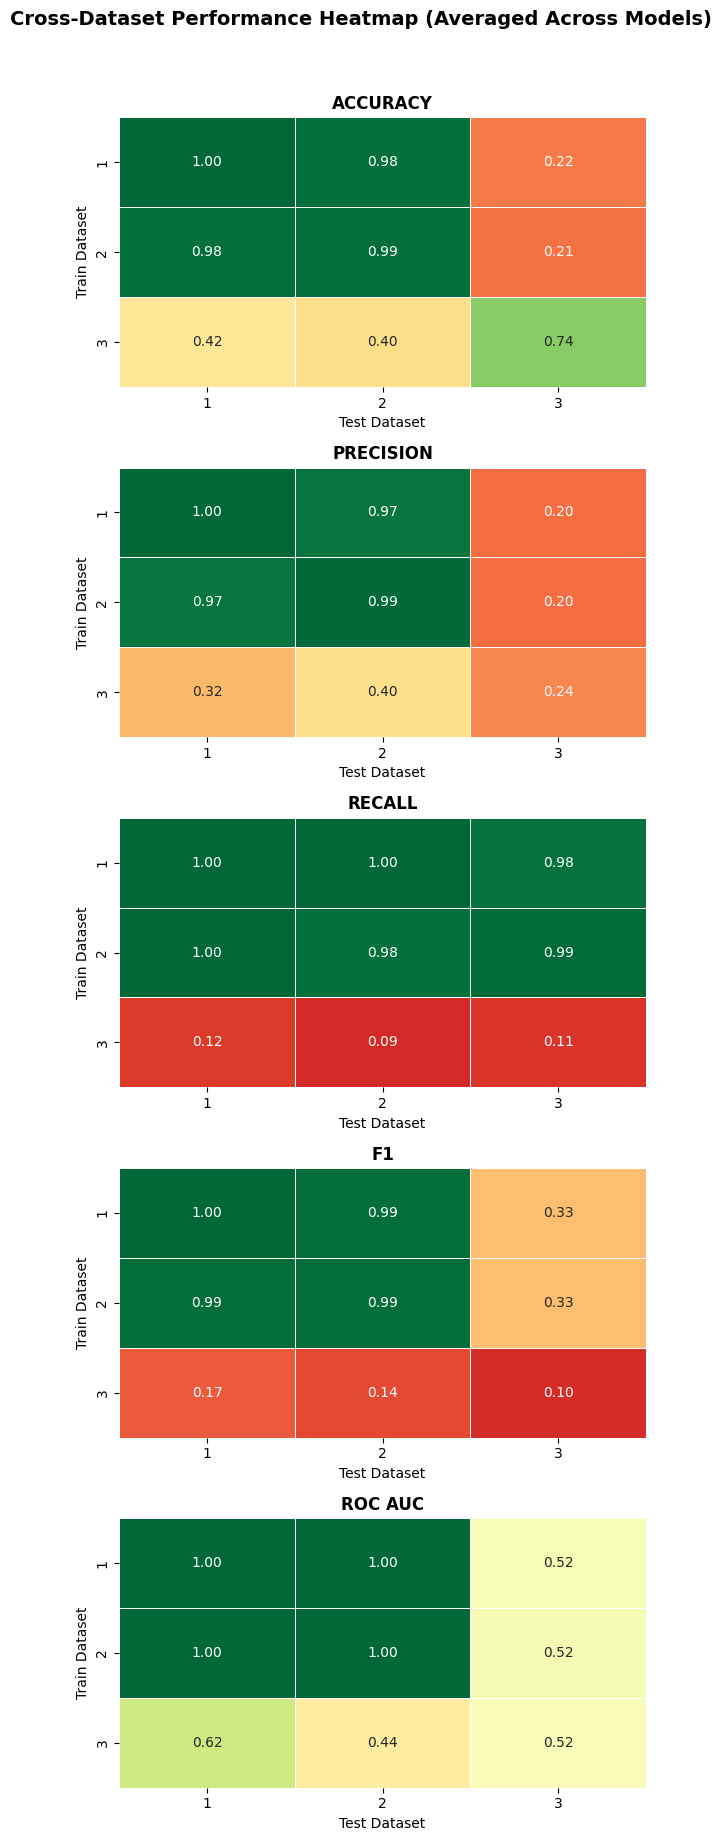

In [83]:
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
fig, axes = plt.subplots(len(metrics), 1, figsize=(6, 18)) 

for ax, metric in zip(axes, metrics):
    pivot = results_df.groupby(['train_dataset', 'test_dataset'])[metric].mean().unstack()
    
    sns.heatmap(
        pivot,
        ax=ax,
        annot=True,
        fmt=".2f",
        cmap="RdYlGn",
        vmin=0,
        vmax=1,
        linewidths=0.5,
        cbar=False
    )
    
    ax.set_title(metric.upper().replace('_', ' '), fontsize=12, fontweight='bold')
    ax.set_xlabel('Test Dataset')
    ax.set_ylabel('Train Dataset')

plt.suptitle('Cross-Dataset Performance Heatmap (Averaged Across Models)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Bar Chart Comparing Balancing VS No Balancing Across Models

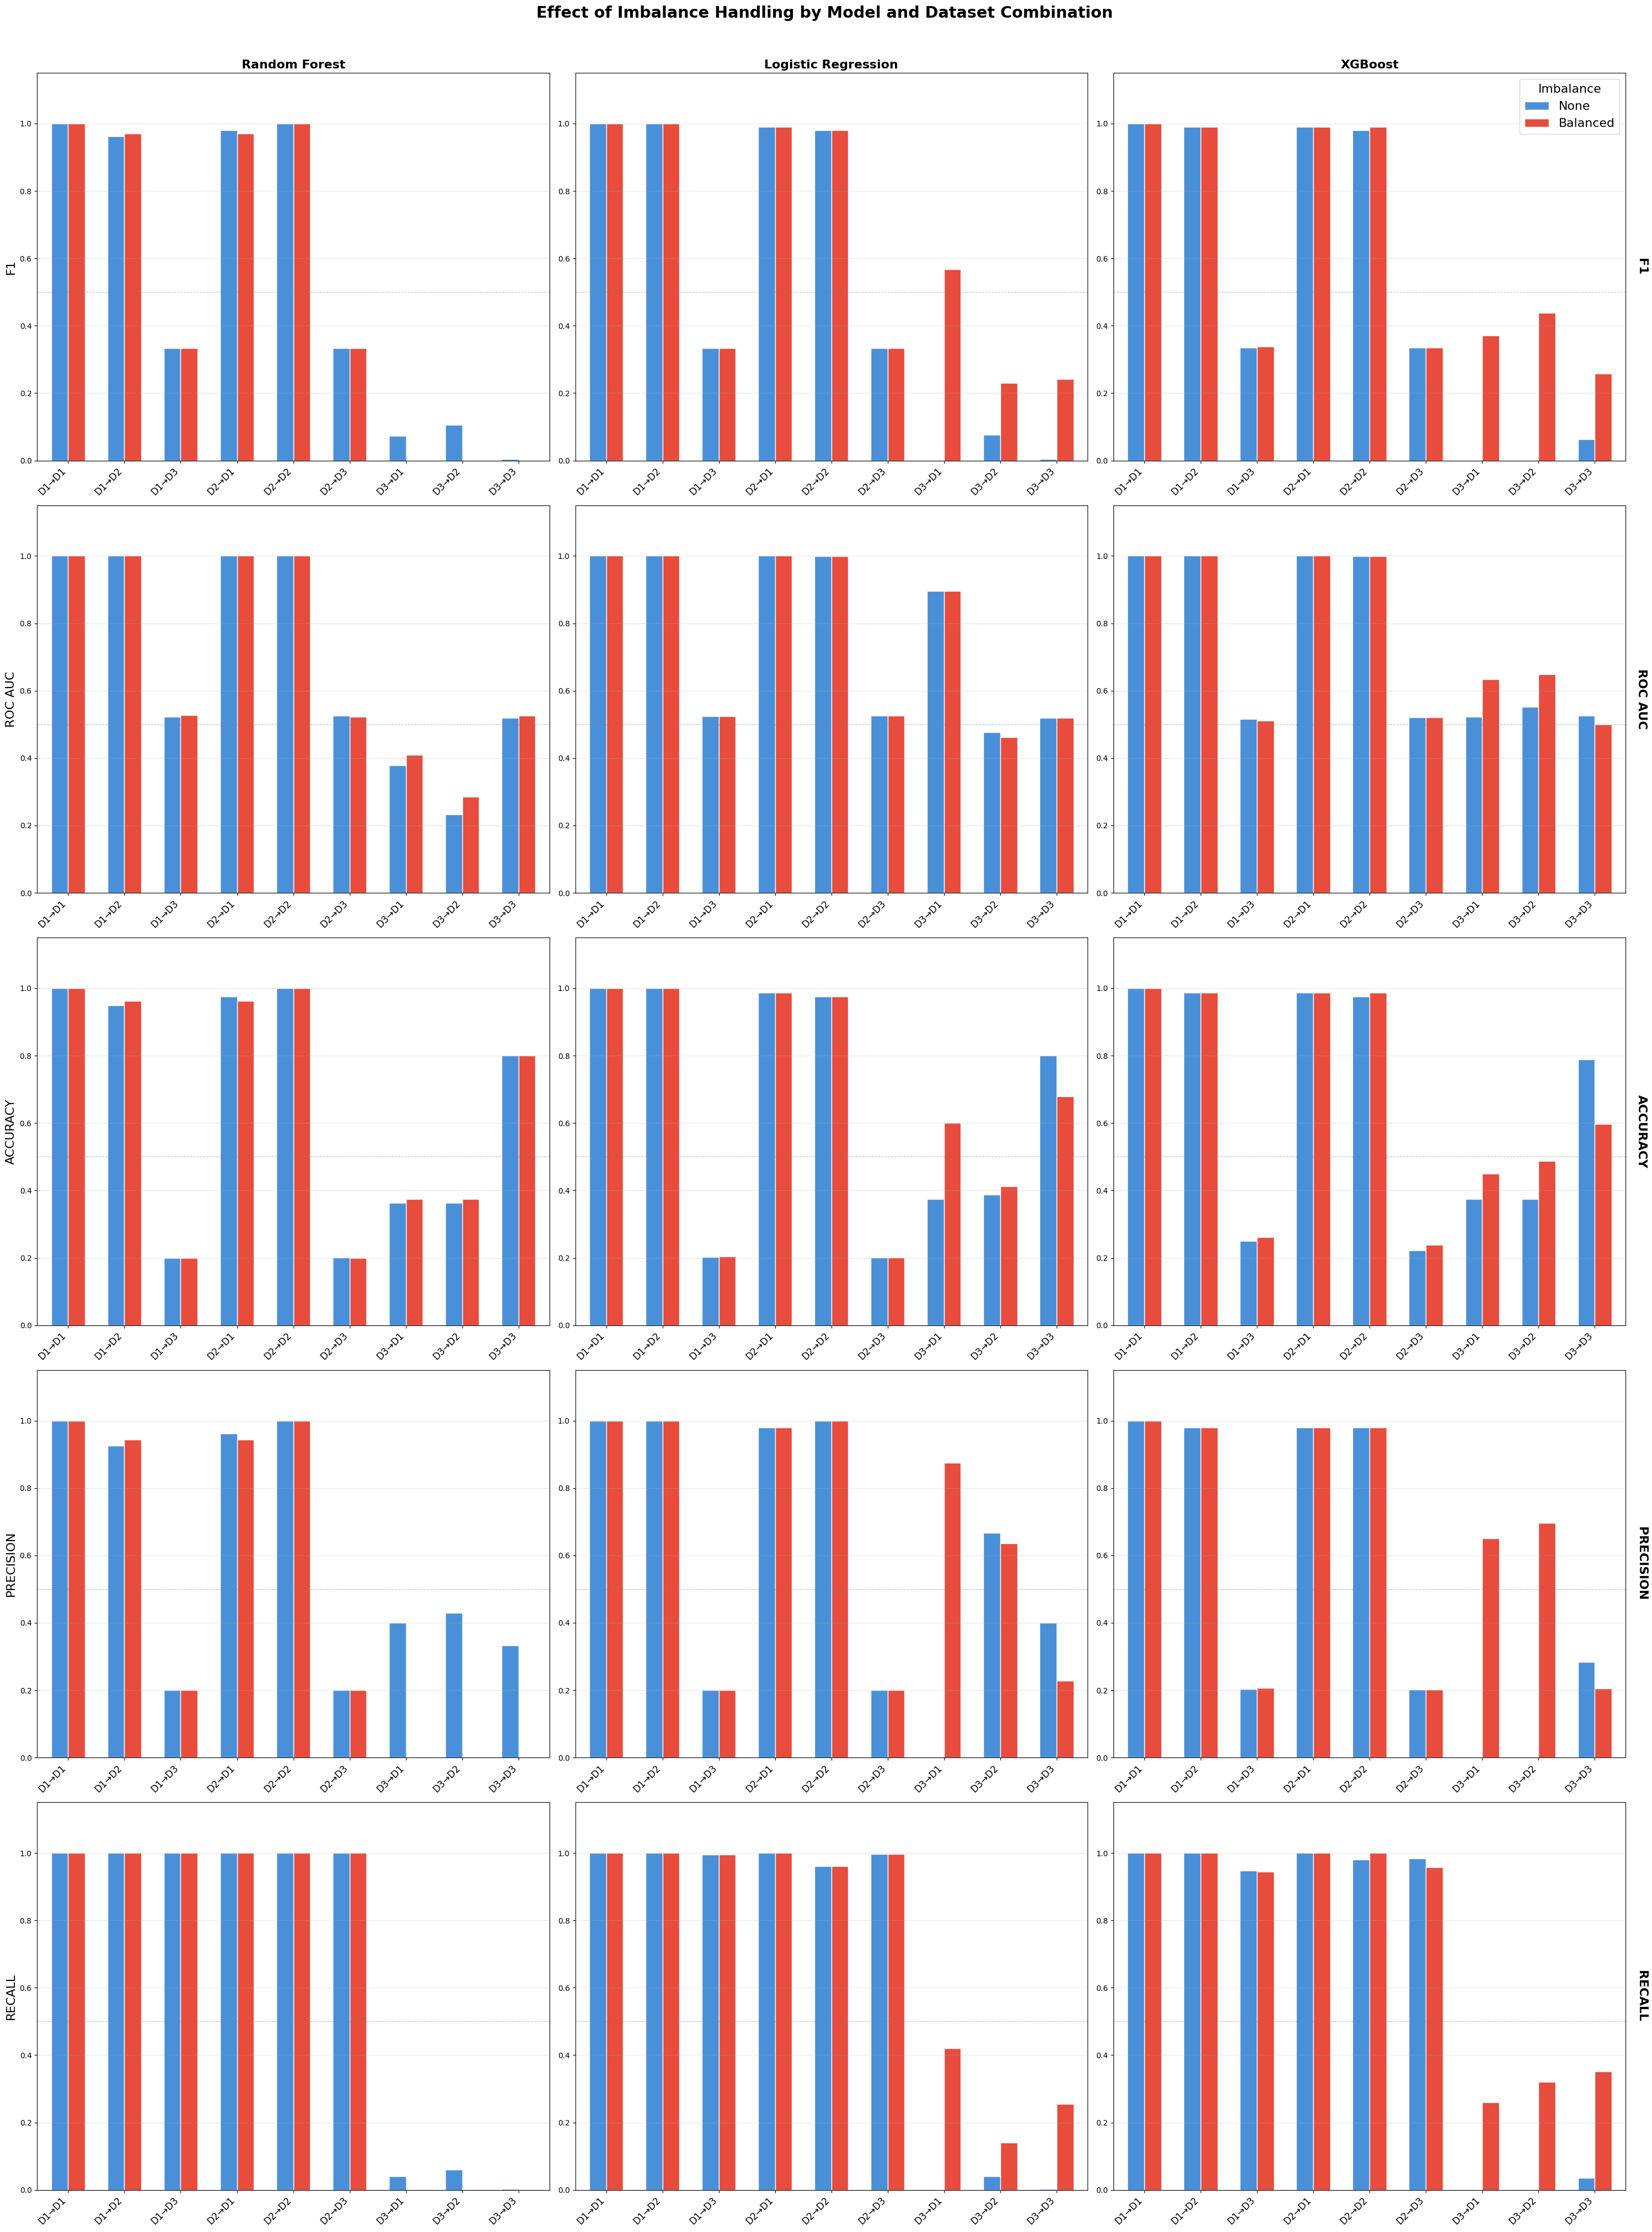

In [84]:
metrics = ['f1', 'roc_auc', 'accuracy', 'precision', 'recall']
models = results_df['model'].unique()

n_rows = len(metrics)
n_cols = len(models)

# Scale figure and fonts dynamically
col_w, row_h = 10, 8
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * col_w, n_rows * row_h))

# Scale fonts relative to subplot size
base_font = min(col_w, row_h) * 1.8
title_font = base_font * 1.1
tick_font  = base_font * 0.85
label_font = base_font * 1.1

for row, metric in enumerate(metrics):
    for col, model in enumerate(models):
        ax = axes[row, col]

        plot_data = []
        for imbalance in ['None', 'Balanced']:
            subset = results_df[
                (results_df['model'] == model) &
                (results_df['imbalance_handling'] == imbalance)
            ].copy()

            subset['experiment'] = 'D' + subset['train_dataset'].astype(str) + '→D' + subset['test_dataset'].astype(str)
            subset['label'] = imbalance
            plot_data.append(subset[['experiment', 'label', metric]])

        plot_df = pd.concat(plot_data)
        pivot = plot_df.pivot_table(index='experiment', columns='label', values=metric)
        pivot = pivot[['None', 'Balanced']]

        pivot.plot(
            kind='bar',
            ax=ax,
            width=0.6,
            color=['#4A90D9', '#E74C3C'],
            edgecolor='white'
        )

        # Only show model name on top row
        ax.set_title(model if row == 0 else '', fontsize=title_font, fontweight='bold')

        # Only show metric label on left column
        ax.set_ylabel(metric.upper().replace('_', ' ') if col == 0 else '', fontsize=label_font)
        ax.set_xlabel('')

        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=tick_font)
        ax.set_ylim(0, 1.15)
        ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.grid(axis='y', alpha=0.3)

        # Only show legend on top-right subplot
        if row == 0 and col == n_cols - 1:
            ax.legend(title='Imbalance', fontsize=label_font, title_fontsize=label_font)
        else:
            ax.get_legend().remove()

# Add row labels (metrics) on the right side
for row, metric in enumerate(metrics):
    axes[row, -1].annotate(
        metric.upper().replace('_', ' '),
        xy=(1.02, 0.5), xycoords='axes fraction',
        fontsize=label_font, fontweight='bold',
        va='center', ha='left', rotation=270
    )

plt.suptitle(
    'Effect of Imbalance Handling by Model and Dataset Combination',
    fontsize=title_font * 1.3, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()